In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/4
    print("準備完了！このまま下のセルを実行できます。")

# 4.1 識別関数 (Discriminant Functions)

本ノートブックでは、入力ベクトル $\mathbf{x}$ を離散クラス $\mathcal{C}_k$ に割り当てる**線形識別関数 (Linear Discriminant Functions)** を扱います。
決定超平面の幾何学（**PRML Figure 4.1**）、多クラス分類における曖昧領域の解消（**PRML Figure 4.2, 4.3**）、最小二乗分類器とその外れ値への脆弱性（**PRML Figure 4.4, 4.5**）、クラス間分離とクラス内凝集度を最適化する**フィッシャーの線形判別分析 (PRML Figure 4.6)**、および歴史的に重要な**パーセプトロンアルゴリズムと収束定理 (PRML Figure 4.7)** を網羅的に理論展開・実装・可視化します。

## 4.1.1 2クラスの線形識別関数の幾何学 (Geometry of Linear Discriminant)

線形識別関数は最も単純には以下のように定義されます：
$$ y(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + w_0 $$
ここで $\mathbf{w}$ は重みベクトル、$w_0$ はバイアスパラメータです。
入力 $\mathbf{x}$ は $y(\mathbf{x}) \ge 0$ のときクラス $\mathcal{C}_1$、$y(\mathbf{x}) < 0$ のときクラス $\mathcal{C}_2$ に割り当てられます。
対応する決定境界は $y(\mathbf{x}) = 0$ で定義される $(D-1)$ 次元の超平面です。

### 幾何学的性質 (PRML Figure 4.1)
1. **法線ベクトル**:
   決定超平面上の任意の2点 $\mathbf{x}_A, \mathbf{x}_B$ に対して $y(\mathbf{x}_A) = y(\mathbf{x}_B) = 0$ であるため、
   $$ \mathbf{w}^T (\mathbf{x}_A - \mathbf{x}_B) = 0 $$
   が成り立ちます。すなわち、重みベクトル $\mathbf{w}$ は決定超平面内のすべてのベクトルと直交し、**超平面の法線ベクトル**となります。
2. **原点からの符号付き直交距離**:
   超平面上の点 $\mathbf{x}$ に対し、原点から超平面への正射影は $\mathbf{x}_{\perp} = \frac{\mathbf{w}}{\|\mathbf{w}\|} d$ と表され、$y(\mathbf{x}_{\perp}) = 0$ より
   $$ d = -\frac{w_0}{\|\mathbf{w}\|} $$
3. **任意の点 $\mathbf{x}$ から超平面への直交距離**:
   点 $\mathbf{x}$ を超平面上の正射影点 $\mathbf{x}_{\perp}$ と法線方向の距離 $r$ を用いて $\mathbf{x} = \mathbf{x}_{\perp} + r \frac{\mathbf{w}}{\|\mathbf{w}\|}$ と分解すると、
   $$ y(\mathbf{x}) = \mathbf{w}^T \left(\mathbf{x}_{\perp} + r \frac{\mathbf{w}}{\|\mathbf{w}\|}\right) + w_0 = \underbrace{y(\mathbf{x}_{\perp})}_{0} + r \|\mathbf{w}\| \implies r = \frac{y(\mathbf{x})}{\|\mathbf{w}\|} $$
   すなわち、$y(\mathbf{x})$ の値そのものが超平面からの符号付き距離に比例します。

Plot saved to: result/fig4_1_geometry.png


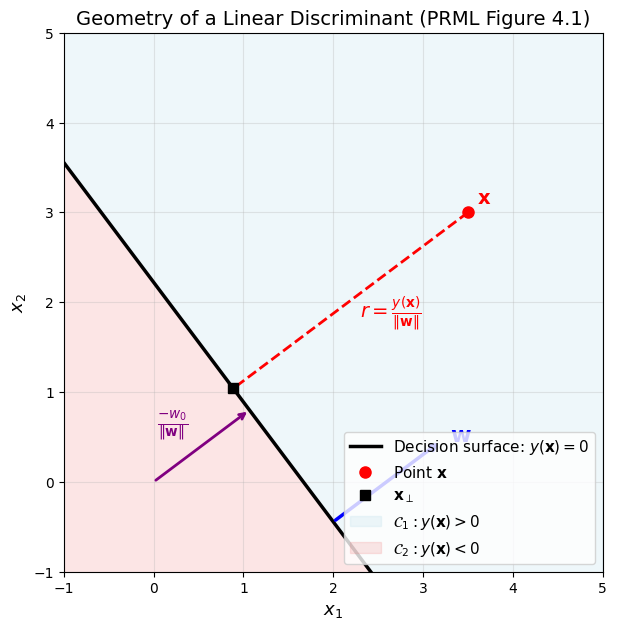

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# PRML Figure 4.1 幾何学的構造の可視化
fig, ax = plt.subplots(figsize=(8, 7))

# 決定境界: w1 * x1 + w2 * x2 + w0 = 0
w = np.array([1.2, 0.9])
w_norm = np.linalg.norm(w)
w_hat = w / w_norm
w0 = -2.0

# 境界線上の点
x1_line = np.linspace(-1, 5, 200)
x2_line = -(w[0] * x1_line + w0) / w[1]
ax.plot(x1_line, x2_line, 'k-', lw=2.5, label=r'Decision surface: $y(\mathbf{x}) = 0$')

# 原点から超平面への垂線
d_orig = -w0 / w_norm
p_orig = d_orig * w_hat
ax.annotate('', xy=p_orig, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='purple', lw=2))
ax.text(p_orig[0]/2 - 0.5, p_orig[1]/2 + 0.2, r'$\frac{-w_0}{\|\mathbf{w}\|}$', fontsize=14, color='purple')

# 法線ベクトル w の表示
p_mid = np.array([2.0, -(w[0]*2.0 + w0)/w[1]])
ax.annotate('', xy=p_mid + w_hat * 1.5, xytext=p_mid,
            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.text(p_mid[0] + w_hat[0]*1.5 + 0.1, p_mid[1] + w_hat[1]*1.5, r'$\mathbf{w}$', fontsize=16, color='blue')

# 任意の点 x と射影点 x_perp
x_arb = np.array([3.5, 3.0])
y_val = np.dot(w, x_arb) + w0
r_dist = y_val / w_norm
x_perp = x_arb - r_dist * w_hat

ax.plot([x_arb[0], x_perp[0]], [x_arb[1], x_perp[1]], 'r--', lw=2)
ax.plot(x_arb[0], x_arb[1], 'ro', markersize=8, label=r'Point $\mathbf{x}$')
ax.plot(x_perp[0], x_perp[1], 'ks', markersize=7, label=r'$\mathbf{x}_\perp$')
ax.text(x_arb[0] + 0.1, x_arb[1] + 0.1, r'$\mathbf{x}$', fontsize=14, color='red')
ax.text(0.5*(x_arb[0]+x_perp[0]) + 0.1, 0.5*(x_arb[1]+x_perp[1]) - 0.2, r'$r = \frac{y(\mathbf{x})}{\|\mathbf{w}\|}$', fontsize=14, color='red')

# 決定領域の着色
ax.fill_between(x1_line, x2_line, 6, color='lightblue', alpha=0.2, label=r'$\mathcal{C}_1: y(\mathbf{x}) > 0$')
ax.fill_between(x1_line, -2, x2_line, color='lightcoral', alpha=0.2, label=r'$\mathcal{C}_2: y(\mathbf{x}) < 0$')

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('Geometry of a Linear Discriminant (PRML Figure 4.1)', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

save_plot(fig, 'result', 'fig4_1_geometry.png')
plt.show()

## 4.1.2 多クラス分類における曖昧領域の解消 (PRML Figure 4.2 & 4.3)

$K$ クラス分類において、2クラス分類器を素朴に組み合わせるアプローチには深刻な欠陥があります：
1. **1-対-他 (one-versus-the-rest) 分類器**:
   各クラス $\mathcal{C}_k$ とそれ以外のクラスを分離する $K-1$ 個の分類器を用いると、複数の分類器が同時に「所属する」と判定したり、どの分類器も「所属しない」と判定する**曖昧領域（グリーン領域）**が生じます（Figure 4.2 左）。
2. **1-対-1 (one-versus-one) 分類器**:
   全ペア $\frac{K(K-1)}{2}$ 個の分類器の多数決をとる手法でも、多数決が三つ巴（引き分け）になる曖昧領域が発生します（Figure 4.2 右）。

### 単一の $K$ クラス線形識別関数 (PRML Figure 4.3)
これらの困難は、$K$ 個の線形関数
$$ y_k(\mathbf{x}) = \mathbf{w}_k^T \mathbf{x} + w_{k0} \quad (k=1, \dots, K) $$
を定義し、**最大値を与えるクラス**に割り当てる規則を採用することで完全に解消されます：
$$ \mathbf{x} \in \mathcal{C}_k \iff y_k(\mathbf{x}) > y_j(\mathbf{x}) \quad (\forall j \neq k) $$
この規則による決定領域 $\mathcal{R}_k$ は常に**単連結かつ凸 (convex)** となり、曖昧領域は生じません。

Plot saved to: result/fig4_2_3_multiclass_ambiguity.png


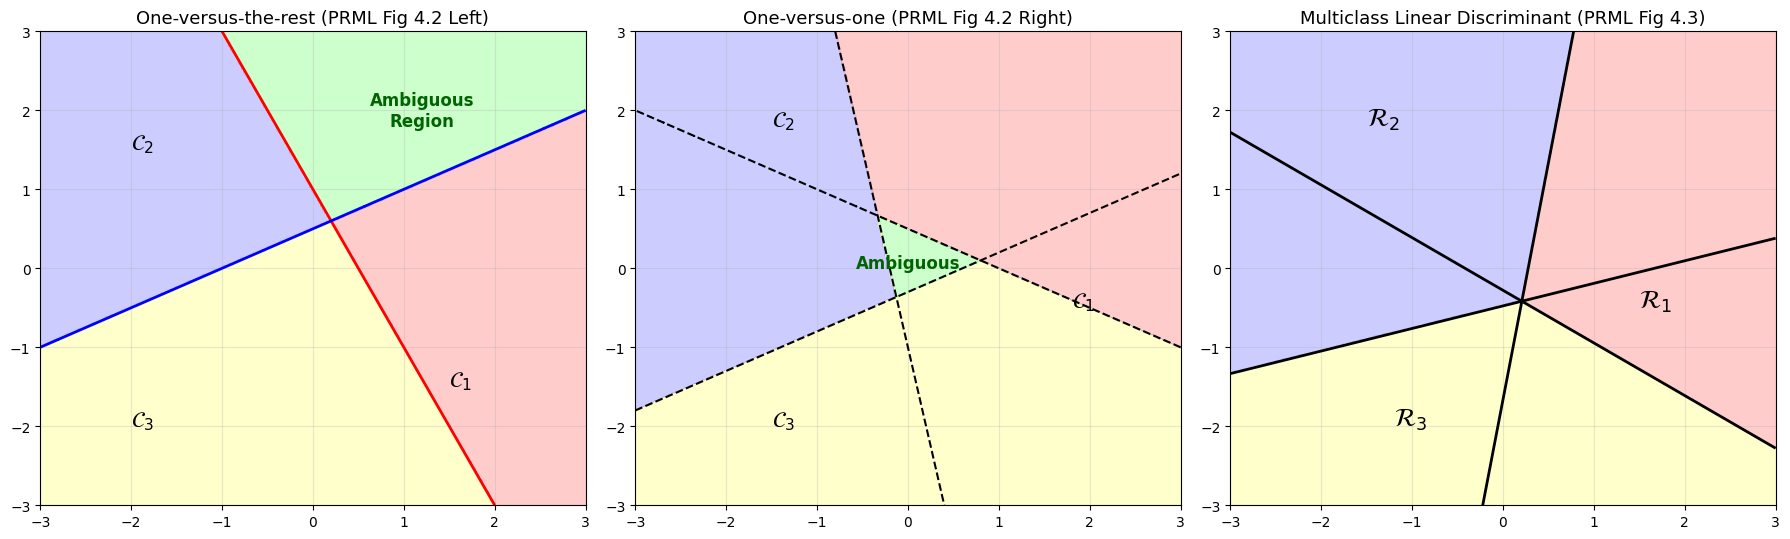

In [2]:
# PRML Figure 4.2 & Figure 4.3 の再現
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

x_grid = np.linspace(-3, 3, 250)
y_grid = np.linspace(-3, 3, 250)
Xg, Yg = np.meshgrid(x_grid, y_grid)
pts = np.c_[Xg.ravel(), Yg.ravel()]

# (1) Figure 4.2 (Left): 1-vs-rest の曖昧領域
# 2つの識別境界 y1(x) = 0, y2(x) = 0
w1 = np.array([1.0, 0.5]); b1 = -0.5
w2 = np.array([-0.5, 1.0]); b2 = -0.5

val1 = pts @ w1 + b1
val2 = pts @ w2 + b2

# 領域判定
reg_c1 = (val1 > 0) & (val2 <= 0)
reg_c2 = (val1 <= 0) & (val2 > 0)
reg_c3 = (val1 <= 0) & (val2 <= 0)
reg_amb = (val1 > 0) & (val2 > 0) # どちらも C1, C2 と主張する曖昧領域

grid_type = np.zeros(len(pts))
grid_type[reg_c1] = 1
grid_type[reg_c2] = 2
grid_type[reg_c3] = 3
grid_type[reg_amb] = 4 # 曖昧

cmap_custom = plt.matplotlib.colors.ListedColormap(['#ffaaaa', '#aaaaff', '#ffffaa', '#aaffaa'])
axes[0].contourf(Xg, Yg, grid_type.reshape(Xg.shape), cmap=cmap_custom, alpha=0.6)
axes[0].contour(Xg, Yg, val1.reshape(Xg.shape), levels=[0], colors='r', linewidths=2)
axes[0].contour(Xg, Yg, val2.reshape(Xg.shape), levels=[0], colors='b', linewidths=2)
axes[0].text(1.5, -1.5, r'$\mathcal{C}_1$', fontsize=16, fontweight='bold')
axes[0].text(-2.0, 1.5, r'$\mathcal{C}_2$', fontsize=16, fontweight='bold')
axes[0].text(-2.0, -2.0, r'$\mathcal{C}_3$', fontsize=16, fontweight='bold')
axes[0].text(1.2, 1.8, 'Ambiguous\nRegion', fontsize=12, color='darkgreen', fontweight='bold', ha='center')
axes[0].set_title('One-versus-the-rest (PRML Fig 4.2 Left)', fontsize=13)
axes[0].set_xlim(-3, 3); axes[0].set_ylim(-3, 3)
axes[0].grid(True, alpha=0.3)

# (2) Figure 4.2 (Right): 1-vs-1 の曖昧領域
# 3つのペアワイズ分類器 y12, y23, y31
val12 = pts @ np.array([1.0, 0.2]) + 0.2
val23 = pts @ np.array([-0.5, 1.0]) + 0.3
val31 = pts @ np.array([-0.5, -1.0]) + 0.5

# 多数決: 各クラスの獲得票数
votes1 = (val12 > 0).astype(int) + (val31 <= 0).astype(int)
votes2 = (val12 <= 0).astype(int) + (val23 > 0).astype(int)
votes3 = (val23 <= 0).astype(int) + (val31 > 0).astype(int)

winner = np.argmax(np.c_[votes1, votes2, votes3], axis=1) + 1
amb_1v1 = (votes1 == 1) & (votes2 == 1) & (votes3 == 1)
winner[amb_1v1] = 4

axes[1].contourf(Xg, Yg, winner.reshape(Xg.shape), cmap=cmap_custom, alpha=0.6)
axes[1].contour(Xg, Yg, val12.reshape(Xg.shape), levels=[0], colors='k', linestyles='--')
axes[1].contour(Xg, Yg, val23.reshape(Xg.shape), levels=[0], colors='k', linestyles='--')
axes[1].contour(Xg, Yg, val31.reshape(Xg.shape), levels=[0], colors='k', linestyles='--')
axes[1].text(1.8, -0.5, r'$\mathcal{C}_1$', fontsize=16, fontweight='bold')
axes[1].text(-1.5, 1.8, r'$\mathcal{C}_2$', fontsize=16, fontweight='bold')
axes[1].text(-1.5, -2.0, r'$\mathcal{C}_3$', fontsize=16, fontweight='bold')
axes[1].text(0.0, 0.0, 'Ambiguous', fontsize=12, color='darkgreen', fontweight='bold', ha='center')
axes[1].set_title('One-versus-one (PRML Fig 4.2 Right)', fontsize=13)
axes[1].set_xlim(-3, 3); axes[1].set_ylim(-3, 3)
axes[1].grid(True, alpha=0.3)

# (3) Figure 4.3: 単一の K クラス線形識別関数
W_k = np.array([[1.0, 0.5], [-0.8, 0.8], [-0.2, -1.3]])
b_k = np.array([0.0, 0.5, -0.5])
scores = pts @ W_k.T + b_k
pred_k = np.argmax(scores, axis=1) + 1

cmap_clean = plt.matplotlib.colors.ListedColormap(['#ffaaaa', '#aaaaff', '#ffffaa'])
axes[2].contourf(Xg, Yg, pred_k.reshape(Xg.shape), cmap=cmap_clean, alpha=0.6)
for k in range(3):
    for j in range(k+1, 3):
        # 境界: y_k - y_j = 0
        diff_w = W_k[k] - W_k[j]
        diff_b = b_k[k] - b_k[j]
        axes[2].contour(Xg, Yg, (pts @ diff_w + diff_b).reshape(Xg.shape), levels=[0], colors='k', linewidths=2)

axes[2].text(1.5, -0.5, r'$\mathcal{R}_1$', fontsize=18, fontweight='bold')
axes[2].text(-1.5, 1.8, r'$\mathcal{R}_2$', fontsize=18, fontweight='bold')
axes[2].text(-1.2, -2.0, r'$\mathcal{R}_3$', fontsize=18, fontweight='bold')
axes[2].set_title('Multiclass Linear Discriminant (PRML Fig 4.3)', fontsize=13)
axes[2].set_xlim(-3, 3); axes[2].set_ylim(-3, 3)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig4_2_3_multiclass_ambiguity.png')
plt.show()

## 4.1.3 最小二乗法による分類とその脆弱性 (PRML Figure 4.4 & 4.5)

目的変数を 1-of-$K$ 符号化（2クラスなら $t \in \{-1, +1\}$ または $\{0, 1\}$）し、線形回帰の二乗和誤差を最小化するアプローチ：
$$ \mathbf{W} = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{T} $$
は閉形式で解が求まるため一見便利ですが、**外れ値に対して致命的な脆弱性**を持ちます。

### なぜ最小二乗法は失敗するのか？
二乗損失 $(y(\mathbf{x}) - 1)^2$ は、決定境界から正しく分類されている側に**非常に遠く離れたデータ点**（$y(\mathbf{x}) = 5$ など）に対しても、「1から離れている」として**巨大な誤差ペナルティを課してしまいます**。
その結果、決定境界が正しく分類された遠方の点に引っ張られて大きく傾いてしまい、境界付近のデータ点を誤分類するようになります（PRML Figure 4.4）。

Plot saved to: result/fig4_4_least_squares_outlier.png


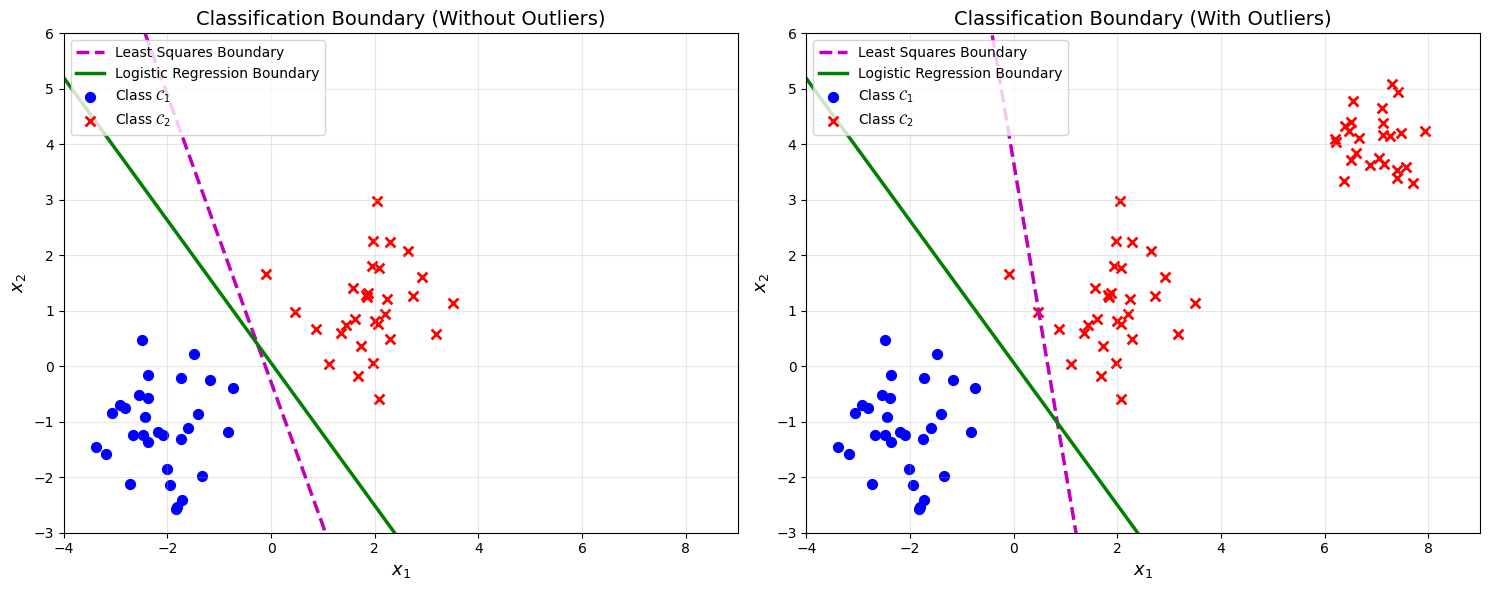

In [3]:
# PRML Figure 4.4 の完全再現: 外れ値による最小二乗境界の破綻とロジスティック回帰の頑健性
from common.classification_utils import LogisticRegression

np.random.seed(42)

# クラス1 (青) と クラス2 (赤)
N1 = 30; N2 = 30
X1 = np.random.randn(N1, 2) * 0.8 + np.array([-2.0, -1.0])
X2 = np.random.randn(N2, 2) * 0.8 + np.array([2.0, 1.0])

X_clean = np.vstack([X1, X2])
y_clean = np.array([-1]*N1 + [1]*N2) # 最小二乗用
t_clean = np.array([0]*N1 + [1]*N2)  # ロジスティック回帰用

# 外れ値の追加 (正しく分類される遠方に多数配置)
X_outliers = np.random.randn(25, 2) * 0.5 + np.array([7.0, 4.0])
y_outliers = np.array([1]*25)
t_outliers = np.array([1]*25)

X_corrupt = np.vstack([X_clean, X_outliers])
y_corrupt = np.concatenate([y_clean, y_outliers])
t_corrupt = np.concatenate([t_clean, t_outliers])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

datasets_plot = [(X_clean, y_clean, t_clean, 'Without Outliers'),
                 (X_corrupt, y_corrupt, t_corrupt, 'With Outliers')]

for idx, (X_d, y_d, t_d, title_suffix) in enumerate(datasets_plot):
    ax = axes[idx]
    Phi_d = np.column_stack([np.ones(len(X_d)), X_d])
    
    # 1. 最小二乗法による決定境界: w_LS = (Phi^T Phi)^-1 Phi^T y
    w_ls = np.linalg.pinv(Phi_d) @ y_d
    
    # 2. ロジスティック回帰による決定境界
    lr = LogisticRegression(alpha=0.0).fit(Phi_d, t_d)
    w_lr = lr.w
    
    # プロット用グリッド
    x1_span = np.linspace(-5, 9, 200)
    # 最小二乗の境界: w0 + w1*x1 + w2*x2 = 0
    x2_ls = -(w_ls[0] + w_ls[1] * x1_span) / w_ls[2]
    # ロジスティック回帰の境界: w0 + w1*x1 + w2*x2 = 0
    x2_lr = -(w_lr[0] + w_lr[1] * x1_span) / w_lr[2]
    
    ax.plot(x1_span, x2_ls, 'm--', lw=2.5, label='Least Squares Boundary')
    ax.plot(x1_span, x2_lr, 'g-', lw=2.5, label='Logistic Regression Boundary')
    
    # 散布図
    ax.scatter(X_d[t_d == 0, 0], X_d[t_d == 0, 1], c='b', marker='o', s=50, label='Class $\mathcal{C}_1$')
    ax.scatter(X_d[t_d == 1, 0], X_d[t_d == 1, 1], c='r', marker='x', s=50, lw=2, label='Class $\mathcal{C}_2$')
    
    ax.set_xlim(-4, 9)
    ax.set_ylim(-3, 6)
    ax.set_xlabel('$x_1$', fontsize=13)
    ax.set_ylabel('$x_2$', fontsize=13)
    ax.set_title(f'Classification Boundary ({title_suffix})', fontsize=14)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig4_4_least_squares_outlier.png')
plt.show()

## 4.1.4 フィッシャーの線形判別分析 (Fisher's Linear Discriminant)

フィッシャーの線形判別 (Fisher, 1936) は、分類を**次元削減**の観点から捉えます。
$D$ 次元の入力 $\mathbf{x}$ を重みベクトル $\mathbf{w}$ を用いて1次元に射影します：
$$ y = \mathbf{w}^T \mathbf{x} $$

### フィッシャー基準の最大化 (PRML Figure 4.6)
単純に射影後のクラス平均の差 $|m_2 - m_1|$ を最大化するだけでは、クラス内の分散が大きい方向に伸びている場合に射影空間で激しい重なりが生じます。
そこでフィッシャーは、**クラス間分散 (between-class variance) を最大化**しつつ、**クラス内分散 (within-class variance) を最小化**する基準を提案しました：
$$ J(\mathbf{w}) = \frac{(m_2 - m_1)^2}{s_1^2 + s_2^2} = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}} $$
ここで
- クラス間共分散行列: $\mathbf{S}_B = (\mathbf{m}_2 - \mathbf{m}_1)(\mathbf{m}_2 - \mathbf{m}_1)^T$
- クラス内共分散行列: $\mathbf{S}_W = \sum_{n \in \mathcal{C}_1} (\mathbf{x}_n - \mathbf{m}_1)(\mathbf{x}_n - \mathbf{m}_1)^T + \sum_{n \in \mathcal{C}_2} (\mathbf{x}_n - \mathbf{m}_2)(\mathbf{x}_n - \mathbf{m}_2)^T$

$J(\mathbf{w})$ を $\mathbf{w}$ で微分して 0 と置くことで、最適な射影方向が解析的に導かれます：
$$ \mathbf{w} \propto \mathbf{S}_W^{-1} (\mathbf{m}_2 - \mathbf{m}_1) $$

Plot saved to: result/fig4_6_fisher_projection.png


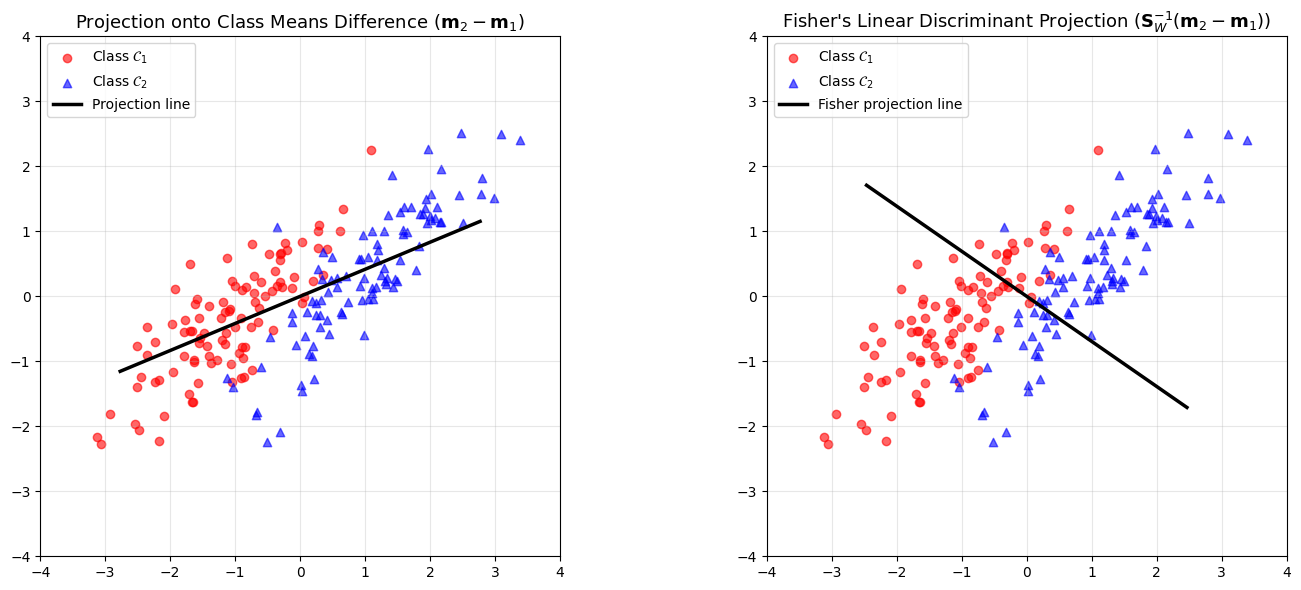

In [4]:
# PRML Figure 4.6 の再現: 単純な平均差射影 vs フィッシャー最適射影
from common.classification_utils import FisherLinearDiscriminant

np.random.seed(42)

# 共分散行列が斜めに強く引き伸ばされた2クラスデータ
N_pts = 100
mean1 = np.array([-1.2, -0.5])
mean2 = np.array([1.2, 0.5])
cov_shared = np.array([[1.0, 0.85], [0.85, 1.0]])

X1_f = np.random.multivariate_normal(mean1, cov_shared, N_pts)
X2_f = np.random.multivariate_normal(mean2, cov_shared, N_pts)
X_f = np.vstack([X1_f, X2_f])
y_f = np.array([0]*N_pts + [1]*N_pts)

# 1. 単純なクラス平均の差の方向
w_naive = (mean2 - mean1)
w_naive = w_naive / np.linalg.norm(w_naive)

# 2. フィッシャーの最適方向
fld = FisherLinearDiscriminant().fit(X_f, y_f)
w_fisher = fld.w

# 射影計算
proj1_naive = X1_f @ w_naive; proj2_naive = X2_f @ w_naive
proj1_fisher = X1_f @ w_fisher; proj2_fisher = X2_f @ w_fisher

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左: 単純射影の散布図とヒストグラム
axes[0].scatter(X1_f[:, 0], X1_f[:, 1], c='r', marker='o', alpha=0.6, label='Class $\mathcal{C}_1$')
axes[0].scatter(X2_f[:, 0], X2_f[:, 1], c='b', marker='^', alpha=0.6, label='Class $\mathcal{C}_2$')
line_pts = np.linspace(-3, 3, 100)
axes[0].plot(line_pts * w_naive[0], line_pts * w_naive[1], 'k-', lw=2.5, label='Projection line')
axes[0].set_title(r'Projection onto Class Means Difference ($\mathbf{m}_2 - \mathbf{m}_1$)', fontsize=13)
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].set_aspect('equal')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# 右: フィッシャー射影の散布図
axes[1].scatter(X1_f[:, 0], X1_f[:, 1], c='r', marker='o', alpha=0.6, label='Class $\mathcal{C}_1$')
axes[1].scatter(X2_f[:, 0], X2_f[:, 1], c='b', marker='^', alpha=0.6, label='Class $\mathcal{C}_2$')
axes[1].plot(line_pts * w_fisher[0], line_pts * w_fisher[1], 'k-', lw=2.5, label='Fisher projection line')
axes[1].set_title(r"Fisher's Linear Discriminant Projection ($\mathbf{S}_W^{-1}(\mathbf{m}_2 - \mathbf{m}_1)$)", fontsize=13)
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4)
axes[1].set_aspect('equal')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig4_6_fisher_projection.png')
plt.show()

## 4.1.7 パーセプトロンアルゴリズム (The Perceptron Algorithm)

パーセプトロン (Rosenblatt, 1958) は、線形モデル $y(\mathbf{x}) = f(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}))$ において、ステップ関数
$$ f(a) = \begin{cases} +1 & (a \ge 0) \\ -1 & (a < 0) \end{cases} $$
を用いる分類器です。

### パーセプトロン誤差基準
誤分類されたサンプルの集合を $\mathcal{M}$ とすると、誤分類点に対しては常に $\mathbf{w}^T \boldsymbol{\phi}_n t_n \le 0$ が成り立ちます。
したがって、最小化すべき誤差関数は以下のように定義されます：
$$ E_P(\mathbf{w}) = -\sum_{n \in \mathcal{M}} \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) t_n $$

### 確率的勾配降下法 (SGD) 更新
誤分類された1点 $(\boldsymbol{\phi}_n, t_n)$ を見つけるたびに、重みを更新します：
$$ \mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} + \eta \boldsymbol{\phi}(\mathbf{x}_n) t_n $$

### パーセプトロン収束定理 (Perceptron Convergence Theorem)
**定理**: 学習データセットが線形分離可能であるならば、パーセプトロン学習アルゴリズムは**有限回の更新ステップで必ず収束**し、すべてのサンプルを正しく分類する重みベクトル $\mathbf{w}^*$ を見つける。

Perceptron converged in 259 weight update steps!


Plot saved to: result/fig4_7_perceptron_convergence.png


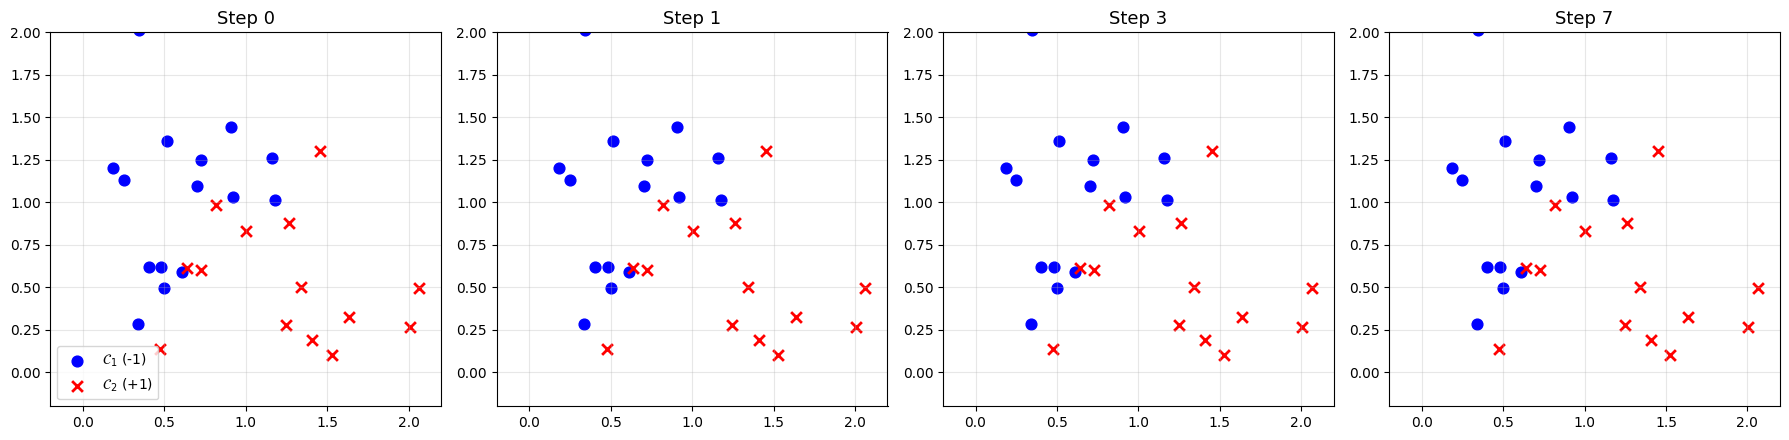

In [5]:
# PRML Figure 4.7 の完全再現: パーセプトロン学習の更新ステップと決定境界の回転
from common.classification_utils import Perceptron

np.random.seed(7)

# 線形分離可能な2クラスデータ
N_sep = 15
X1_p = np.random.randn(N_sep, 2) * 0.4 + np.array([0.5, 1.2])
X2_p = np.random.randn(N_sep, 2) * 0.4 + np.array([1.3, 0.4])
X_perc = np.vstack([X1_p, X2_p])
y_perc = np.array([-1]*N_sep + [1]*N_sep)

# パーセプトロンの学習
perc = Perceptron(max_iter=100, lr=1.0).fit(X_perc, y_perc)

print(f"Perceptron converged in {len(perc.history)-1} weight update steps!")

# 選択したいくつかの反復ステップにおける決定境界を描画
step_indices = [0, 1, 3, min(len(perc.history)-1, 7)]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

x_span = np.linspace(-0.5, 2.5, 100)

for idx, s_idx in enumerate(step_indices):
    ax = axes[idx]
    w_curr = perc.history[s_idx]
    
    # 散布図
    ax.scatter(X1_p[:, 0], X1_p[:, 1], c='b', marker='o', s=60, label=r'$\mathcal{C}_1$ (-1)')
    ax.scatter(X2_p[:, 0], X2_p[:, 1], c='r', marker='x', s=60, lw=2, label=r'$\mathcal{C}_2$ (+1)')
    
    if np.linalg.norm(w_curr[1:]) > 1e-6:
        # 決定境界: w0 + w1*x1 + w2*x2 = 0
        x2_boundary = -(w_curr[0] + w_curr[1] * x_span) / (w_curr[2] + 1e-10)
        ax.plot(x_span, x2_boundary, 'k-', lw=2)
        # 法線ベクトル
        mid_pt = np.array([1.0, -(w_curr[0] + w_curr[1]*1.0)/(w_curr[2] + 1e-10)])
        w_dir = w_curr[1:] / np.linalg.norm(w_curr[1:]) * 0.4
        ax.annotate('', xy=mid_pt + w_dir, xytext=mid_pt,
                    arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
        
    ax.set_title(f'Step {s_idx}', fontsize=13)
    ax.set_xlim(-0.2, 2.2); ax.set_ylim(-0.2, 2.0)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(loc='lower left')

plt.tight_layout()
save_plot(fig, 'result', 'fig4_7_perceptron_convergence.png')
plt.show()